dict_keys(['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma'])
---- Internal Validation Metrics ----
MSE: 0.0008
MAE: 0.0213
RMSE: 0.0277
R2: 0.7159

---- External Validation Metrics ----
MSE: 0.0008
MAE: 0.0213
RMSE: 0.0277
R2: 0.7159


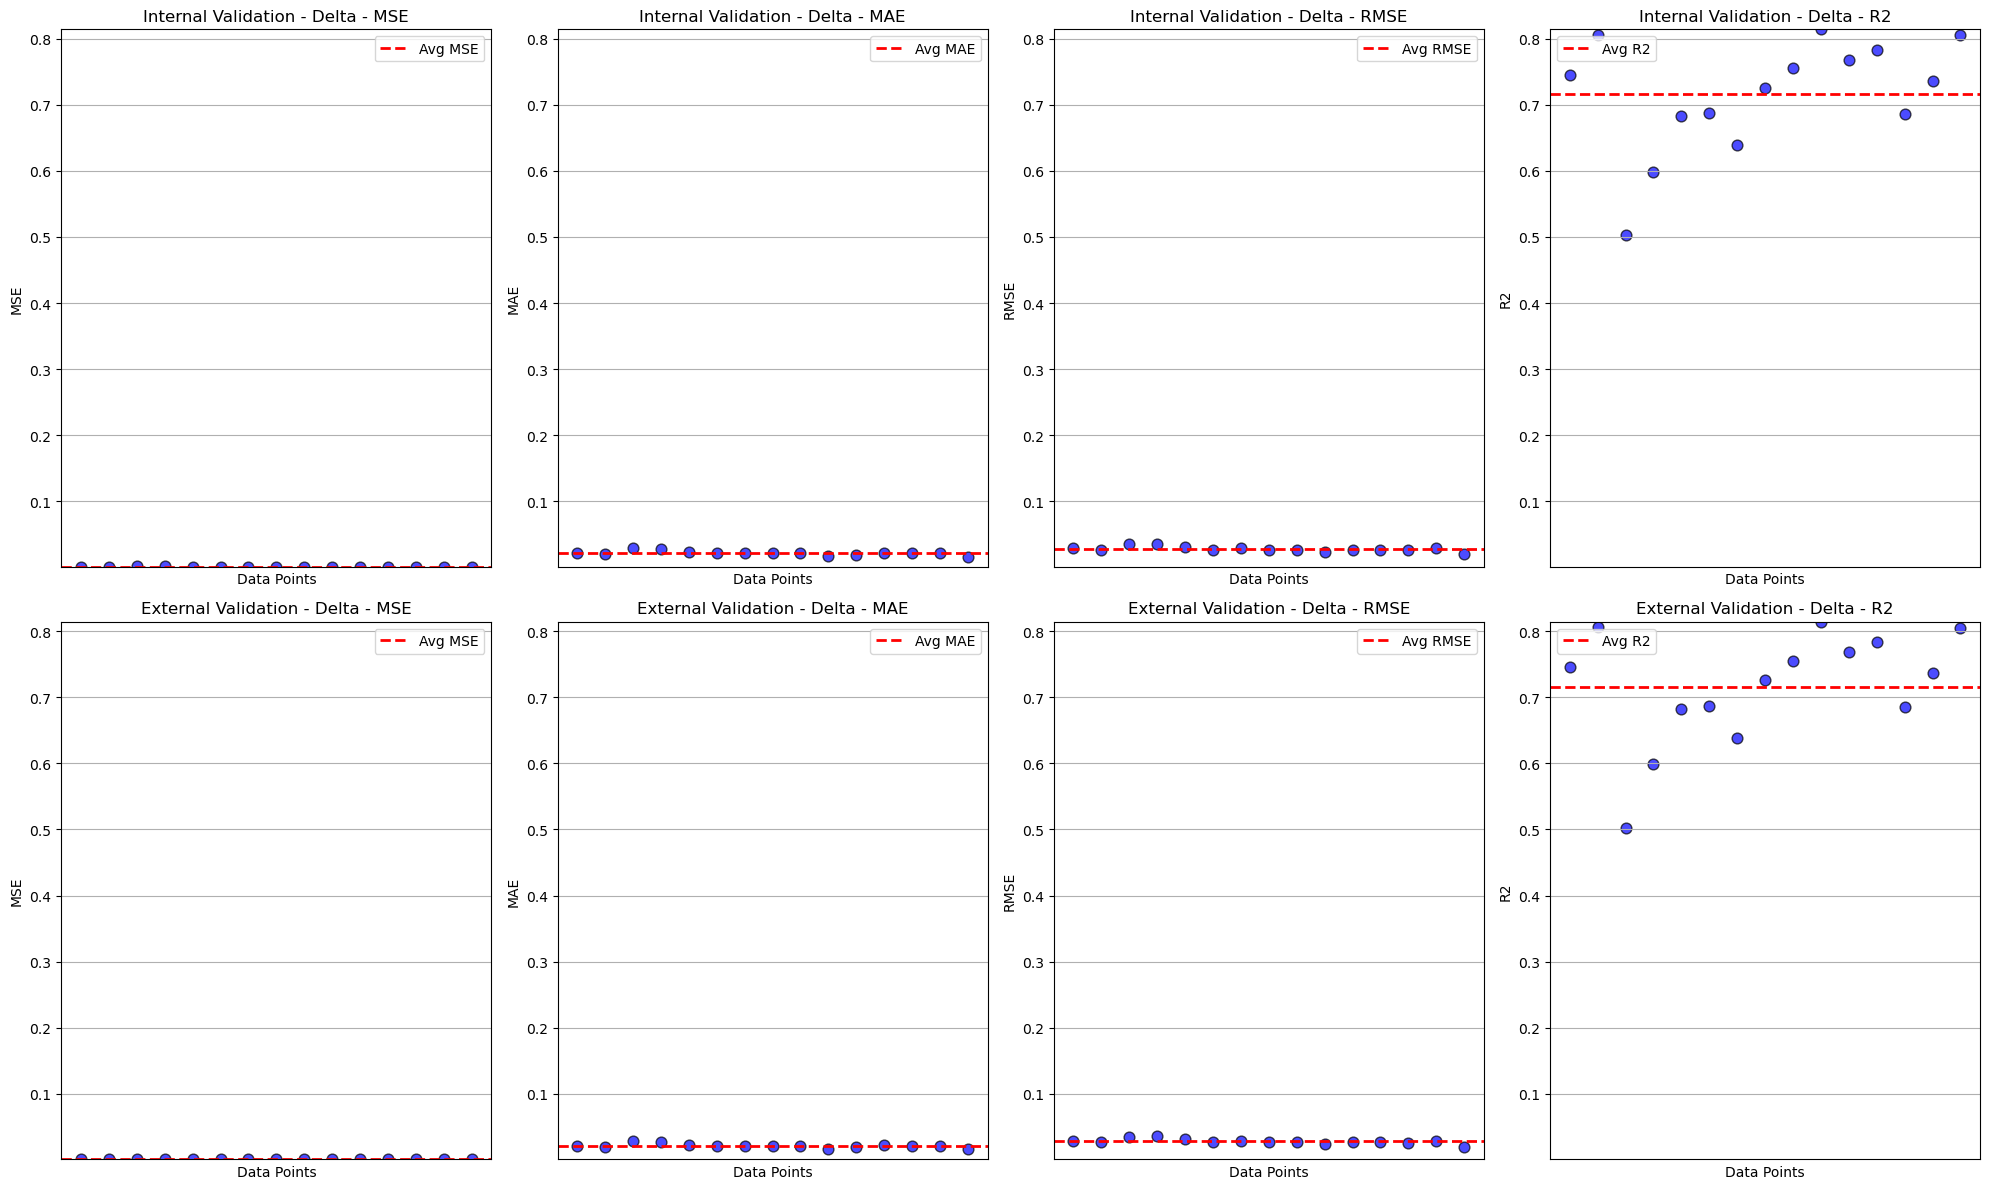

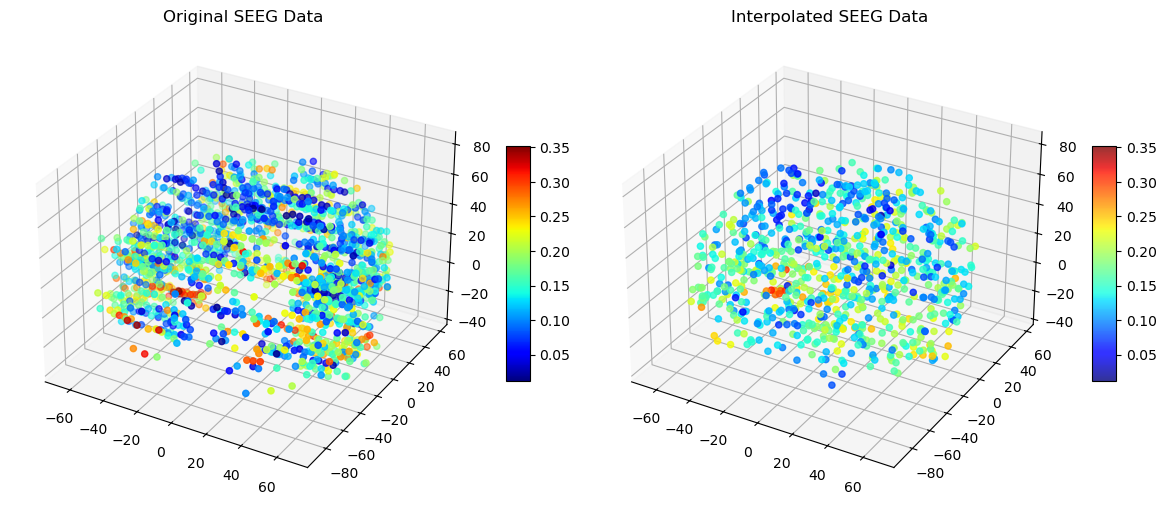

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

def load_data():
    coords = np.load('coords.npy')
    band_powers = np.load('band_powers.npy', allow_pickle=True).item()
    print(band_powers.keys())
    return coords, band_powers

def interpolate_smooth(coords, values, method='linear'):
     

    grid_x = np.linspace(coords[:, 0].min(), coords[:, 0].max(), len(coords))
    grid_y = np.linspace(coords[:, 1].min(), coords[:, 1].max(), len(coords))
    grid_z = np.linspace(coords[:, 2].min(), coords[:, 2].max(), len(coords))

    
    grid_coords = np.column_stack([
        np.random.choice(grid_x, size=len(coords)),  
        np.random.choice(grid_y, size=len(coords)),  
        np.random.choice(grid_z, size=len(coords))
    ])

    
    interp_values = griddata(coords, values, grid_coords, method='linear')

    return grid_coords, interp_values


def plot_3d_data(coords, values, interp_coords, interp_values):
    fig = plt.figure(figsize=(12, 5))

    vmin = min(values.min(), interp_values.min())  
    vmax = max(values.max(), interp_values.max()) 

    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=values, cmap='jet', marker='o', vmin=vmin, vmax=vmax)
    ax1.set_title("Original SEEG Data")
    fig.colorbar(scatter1, ax=ax1, shrink=0.5, aspect=10)

    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(interp_coords[:, 0], interp_coords[:, 1], interp_coords[:, 2], c=interp_values, cmap='jet', marker='o', alpha=0.8, vmin=vmin, vmax=vmax)
    ax2.set_title("Interpolated SEEG Data")
    fig.colorbar(scatter2, ax=ax2, shrink=0.5, aspect=10)

    for ax in [ax1, ax2]:
        ax.set_xlim([coords[:, 0].min(), coords[:, 0].max()])
        ax.set_ylim([coords[:, 1].min(), coords[:, 1].max()])
        ax.set_zlim([coords[:, 2].min(), coords[:, 2].max()])

    plt.tight_layout()
    plt.show()

def linear_interpolation(train_coords, train_values, test_coords):

    pred_values = griddata(train_coords, train_values, test_coords, method='linear')
    return pred_values
    
def calculate_metrics(true_values, pred_values):
    mask = ~np.isnan(pred_values) 
    mse = mean_squared_error(true_values[mask], pred_values[mask])
    mae = mean_absolute_error(true_values[mask], pred_values[mask])
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values[mask], pred_values[mask])
    return {"MSE": mse, "MAE": mae, "RMSE": rmse, "R2": r2}

def plot_scatter(metric_values, metric_name, validation_type, band, ax, avg_value, min_val, max_val):
    ax.set_ylim(min_val, max_val)  
    ax.scatter(np.arange(len(metric_values)), metric_values, alpha=0.7, color='b', edgecolors='black', s=60)  
    ax.set_xticks([])  
    ax.set_xlabel("Data Points")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{validation_type} Validation - {band} - {metric_name}")
    ax.grid(True)

    ax.axhline(y=avg_value, color='red', linestyle='--', linewidth=2, label=f'Avg {metric_name}')
    ax.legend()

def cross_validate(coords, values, k=10, validation_type="Internal", band="Unknown"):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    all_metrics = {"MSE": [], "MAE": [], "RMSE": [], "R2": []}
    
    scaler = StandardScaler()
    coords = scaler.fit_transform(coords)  

    for train_idx, test_idx in kf.split(coords):
        train_coords, test_coords = coords[train_idx], coords[test_idx]
        train_values, test_values = values[train_idx], values[test_idx]
        
        pred_values = griddata(train_coords, train_values, test_coords, method='linear')
        metrics = calculate_metrics(test_values, pred_values)
        
        for metric in all_metrics:
            all_metrics[metric].append(metrics[metric])
    
    return all_metrics

def plot_all_metrics(internal_metrics, external_metrics, band):
    all_values = list(internal_metrics.values()) + list(external_metrics.values())
    all_metrics_values = np.concatenate([np.array(values) for values in all_values])
    min_val, max_val = np.min(all_metrics_values), np.max(all_metrics_values)

    fig, axes = plt.subplots(2, 4, figsize=(20, 12))  # Set the overall plot size

    for i, (metric_name, values) in enumerate(internal_metrics.items()):
        avg_value = np.mean(values)
        ax = axes[0, i]
        plot_scatter(values, metric_name, "Internal", band, ax, avg_value, min_val, max_val)

    for i, (metric_name, values) in enumerate(external_metrics.items()):
        avg_value = np.mean(values)
        ax = axes[1, i]
        plot_scatter(values, metric_name, "External", band, ax, avg_value, min_val, max_val)

    plt.tight_layout()
    plt.show()

def print_metrics(internal_metrics, external_metrics):
    print("---- Internal Validation Metrics ----")
    for metric_name, values in internal_metrics.items():
        avg_value = np.mean(values)
        print(f"{metric_name}: {avg_value:.4f}")

    print("\n---- External Validation Metrics ----")
    for metric_name, values in external_metrics.items():
        avg_value = np.mean(values)
        print(f"{metric_name}: {avg_value:.4f}")

def main():
    coords, band_powers = load_data()
    band = 'Delta' 
    if band not in band_powers:
        print(f"Band {band} not found in data.")
        return
    
    band_values = np.array(band_powers[band])
    interp_coords, interp_values = interpolate_smooth(coords, band_values, method='linear')

    internal_metrics = cross_validate(interp_coords, interp_values, k=15, validation_type="Internal", band=band)
    external_metrics = cross_validate(interp_coords, interp_values, k=15, validation_type="External", band=band)
    print_metrics(internal_metrics, external_metrics)
    plot_all_metrics(internal_metrics, external_metrics, band)

    plot_3d_data(coords, band_values, interp_coords, interp_values)

if __name__ == "__main__":
    main()